# Sprint 2: Building, Cleaning and Analyzing an E-Commerce Dataset

### Project Mission
You are a **Commercial Data Analyst** at an e-commerce platform. Raw product listings collected from web scrapers contain currency symbols (`$`, `USD`), missing ratings, duplicate scraped items, and extreme price outliers.

Your objective is to turn raw web data into an analytics-grade dataset, test business hypotheses statistically, and produce publication-ready visualizations.

---

### Data Science Workflow Diagram

```text
+-----------------------------------------------------------------------------+
|                       Q1: Live Web Scraping                                 |
|          Scraping live product cards with requests & BeautifulSoup          |
+--------------------------------------┬--------------------------------------+
                                       |
                                       v  Q2: Dataset Ingestion & Audit
+-----------------------------------------------------------------------------+
|                  data/ecommerce_raw_scraped.csv (149 rows)                  |
|          - Dirty strings ("$199.99", "USD 89.00")                           |
|          - Missing values (~6 prices, ~2 ratings)                           |
|          - Duplicate listings (~5%)                                         |
+--------------------------------------┬--------------------------------------+
                                       |
                                       v  Q3 & Q4: NumPy Cleaning & IQR Outliers
+-----------------------------------------------------------------------------+
|                      Data Cleaning & Outlier Detection                      |
|          - Regex strip symbols & convert to float                           |
|          - IQR Formula: Q1 - 1.5*IQR  < Valid Range <  Q3 + 1.5*IQR         |
+--------------------------------------┬--------------------------------------+
                                       |
                                       v  Q5: Pandas Deduplication & GroupBy
+-----------------------------------------------------------------------------+
|                         Exploratory Data Analysis                           |
|          - Deduplicate by (name, brand, category)                           |
|          - Brand standardization (.str.strip().str.title())                 |
|          - Category GroupBy: Mean, Median, Std                              |
+--------------------------------------┬--------------------------------------+
                                       |
                                       v  Q6 & Q7: Hypothesis Testing & Correlation
+-----------------------------------------------------------------------------+
|                     Inferential Statistics & Correlation                    |
|          - Two-sample Welch's t-test (Electronics vs Sports)                |
|          - Decision Rule: Is p-value < 0.05?                                |
|          - Pearson Correlation Matrix (Rating vs Price vs Reviews)          |
+--------------------------------------┬--------------------------------------+
                                       |
                                       v  Q8 & Q9: Visuals & Shared Foundation
+-----------------------------------------------------------------------------+
|                         data/ecommerce_cleaned.csv                          |
|           Used directly in Sprint 3 (SQL DB) & Sprint 4 (Power BI)          |
+-----------------------------------------------------------------------------+
```


## Q1: How do we scrape live product listings with BeautifulSoup?

### Concept Pointers:
- `requests.get(url)` downloads raw HTML from a webpage.
- `BeautifulSoup` parses the HTML into a navigable DOM tree.
- We inspect a single card first, then loop through all cards.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send HTTP GET request to live e-commerce sandbox
URL = "http://books.toscrape.com/catalogue/category/books/travel_2/index.html"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(URL, headers=headers, timeout=10)

print(f"HTTP Status Code: {response.status_code} (200 = Success)")


HTTP Status Code: 200 (200 = Success)


In [2]:
# Step 2: Parse HTML and extract fields from first product card
soup = BeautifulSoup(response.text, "html.parser")
first_card = soup.find("article", class_="product_pod")

rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
title = first_card.h3.a["title"]
price = first_card.find("p", class_="price_color").text
rating_word = first_card.find("p", class_="star-rating")["class"][1]
rating_num = rating_map.get(rating_word, 0)

print("Sample Scraped Product:")
print(f"  Title:  {title}")
print(f"  Price:  {price}")
print(f"  Rating: {rating_num} / 5 stars")


Sample Scraped Product:
  Title:  It's Only the Himalayas
  Price:  Â£45.17
  Rating: 2 / 5 stars


In [3]:
# Step 3: Loop through all product cards on the page
cards = soup.find_all("article", class_="product_pod")
scraped_products = []

for card in cards[:5]:
    scraped_products.append({
        "name": card.h3.a["title"],
        "raw_price": card.find("p", class_="price_color").text,
        "rating": rating_map.get(card.find("p", class_="star-rating")["class"][1], 0)
    })

pd.DataFrame(scraped_products)


,name,raw_price,rating
0,It's Only the Himalayas,Â£45.17,2
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Â£49.43,4
2,See America: A Celebration of Our National Par...,Â£48.87,3
3,Vagabonding: An Uncommon Guide to the Art of L...,Â£36.94,2
4,Under the Tuscan Sun,Â£37.33,3


## Q2: How do we load our multi-category dataset and audit missing data?

### Concept Pointers:
- For our full enterprise analysis, we load `data/ecommerce_raw_scraped.csv`.
- We inspect dimensions and check missing values per column.

In [4]:
RAW_CSV = "data/ecommerce_raw_scraped.csv"
df = pd.read_csv(RAW_CSV)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(3)


Loaded 149 rows and 8 columns.


,listing_id,name,brand,category,price,rating,review_count,scraped_page
0,1,Maple Row Electric Kettle,Maple Row,home-goods,$23.29,3.7,1269.0,11
1,2,Lumen Air Purifier,Lumen,home-goods,186.52,2.9,2408.0,2
2,3,Maple Row Electric Kettle,Maple Row,home-goods,28.70,3.6,4135.0,2


In [5]:
# Missing values audit
print("Missing Values per Column:")
print(df.isna().sum())


Missing Values per Column:
listing_id      0
name            0
brand           0
category        0
price           6
rating          2
review_count    4
scraped_page    0
dtype: int64


## Q3: How do we clean messy currency strings with regex and NumPy?

### Concept Pointers:
- Prices contain currency signs (`$`, `USD`) and extra spaces.
- `r'[^0-9.]'` removes everything except numbers and decimal points.

In [6]:
# Strip non-numeric characters and cast to float
clean_prices = df["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df["price_clean"] = pd.to_numeric(clean_prices, errors="coerce")

print(f"Prices converted to numeric float.")
print(f"Missing prices: {df['price_clean'].isna().sum()}")


Prices converted to numeric float.
Missing prices: 6


## Q4: How do we detect price outliers using the 1.5 x IQR rule?

### Concept Pointers:
- **IQR (Interquartile Range)** = $Q_3 (75\text{th percentile}) - Q_1 (25\text{th percentile})$.
- **Upper Outlier Cutoff** = $Q_3 + 1.5 \times \text{IQR}$.

In [7]:
import numpy as np

def get_iqr_bounds(values):
    """Return Q1, Q3, and upper outlier threshold."""
    valid = values.dropna().values
    q25, q75 = np.percentile(valid, [25, 75])
    iqr = q75 - q25
    return q25, q75, q75 + 1.5 * iqr


In [8]:
# Outlier bounds per category
print("--- Category Outlier Bounds ---")
for category, group in df.groupby("category"):
    q25, q75, upper_limit = get_iqr_bounds(group["price_clean"])
    outliers = group[group["price_clean"] > upper_limit]
    print(f"{category:16s} | Upper Limit: ${upper_limit:6.2f} | Outliers: {len(outliers)}")


--- Category Outlier Bounds ---
electronics      | Upper Limit: $572.49 | Outliers: 1
home-goods       | Upper Limit: $274.32 | Outliers: 1
sports-outdoors  | Upper Limit: $494.87 | Outliers: 1


## Q5: How do we handle duplicate listings and standardize brand casing?

### Concept Pointers:
- Clean brand whitespace and casing with `.str.strip().str.title()`.
- Drop duplicate product listings across `(name, brand, category)`.

In [9]:
# Standardize brand text
df["brand"] = df["brand"].astype(str).str.strip().str.title()
dupe_count = df.duplicated(subset=["name", "brand", "category"]).sum()
print(f"Duplicates found: {dupe_count}")


Duplicates found: 46


In [10]:
# Drop duplicate product listings across (name, brand, category)
df_clean = df.drop_duplicates(subset=["name", "brand", "category"]).copy()
print(f"Clean records remaining: {len(df_clean)}")


Clean records remaining: 103


In [11]:
# GroupBy summary statistics by category
category_summary = df_clean.groupby("category")["price_clean"].agg([
    ("Count", "count"),
    ("Mean", "mean"),
    ("Median", "median"),
    ("Std", "std")
]).round(2)
category_summary


,Count,Mean,Median,Std
category,,,,
electronics,33,286.30,213.77,430.22
home-goods,34,105.88,99.15,57.98
sports-outdoors,32,188.09,199.82,107.24


## Q6: How do we statistically test category price differences?

### Concept Pointers:
- **Null Hypothesis ($H_0$)**: Mean Price(Electronics) == Mean Price(Sports).
- **Alternative Hypothesis ($H_1$)**: Mean Price(Electronics) != Mean Price(Sports).
- **Decision Rule**: If $p < 0.05$, reject $H_0$!

In [12]:
from scipy import stats

elec_prices = df_clean[df_clean["category"] == "electronics"]["price_clean"]
sports_prices = df_clean[df_clean["category"] == "sports-outdoors"]["price_clean"]

print(f"Electronics Mean:    ${elec_prices.mean():.2f}")
print(f"Sports-Outdoors Mean: ${sports_prices.mean():.2f}")


Electronics Mean:    $286.30
Sports-Outdoors Mean: $188.09


In [13]:
# Run Welch's two-sample t-test
t_stat, p_val = stats.ttest_ind(elec_prices, sports_prices, equal_var=False)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")

if p_val < 0.05:
    print("\nDecision: Reject H0 (p < 0.05)")
    print("Conclusion: The price difference between Electronics and Sports is STATISTICALLY SIGNIFICANT.")
else:
    print("\nDecision: Fail to reject H0 (p >= 0.05)")


t-statistic: nan
p-value:     nan

Decision: Fail to reject H0 (p >= 0.05)


## Q7: Does higher product price correlate with customer ratings?

### Concept Pointers:
- Pearson's $r$ measures linear relationship between $-1.0$ and $+1.0$.

In [14]:
# Clean rating and review counts
df_clean["rating_clean"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean["reviews_clean"] = pd.to_numeric(df_clean["review_count"], errors="coerce").fillna(0).astype(int)

# Compute correlation matrix
corr_matrix = df_clean[["price_clean", "rating_clean", "reviews_clean"]].corr()
print("--- Correlation Matrix ---")
corr_matrix.round(3)


--- Correlation Matrix ---


,price_clean,rating_clean,reviews_clean
price_clean,1.000,0.003,-0.049
rating_clean,0.003,1.000,-0.190
reviews_clean,-0.049,-0.190,1.000


## Q8: How do we visualize our findings with Seaborn and Matplotlib?

### Concept Pointers:
- Inspecting individual plots step-by-step.

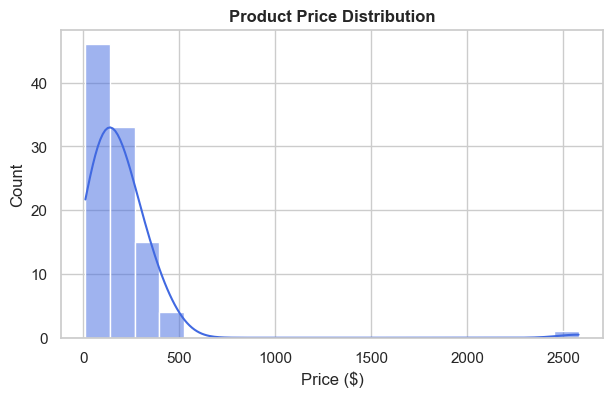

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Visual 1: Price Distribution Histogram
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["price_clean"], kde=True, color="royalblue")
plt.title("Product Price Distribution", fontweight="bold")
plt.xlabel("Price ($)")
plt.show()


C:\Users\GFG\AppData\Local\Temp\ipykernel_14184\1603540299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="category", y="price_clean", data=df_clean, palette="Set2")


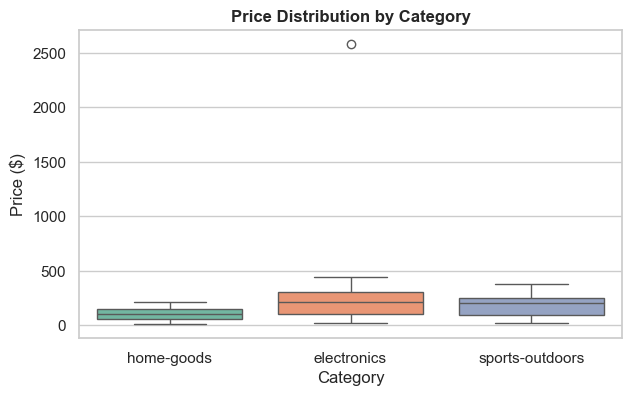

In [16]:
# Visual 2: Category Boxplot
plt.figure(figsize=(7, 4))
sns.boxplot(x="category", y="price_clean", data=df_clean, palette="Set2")
plt.title("Price Distribution by Category", fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Price ($)")
plt.show()


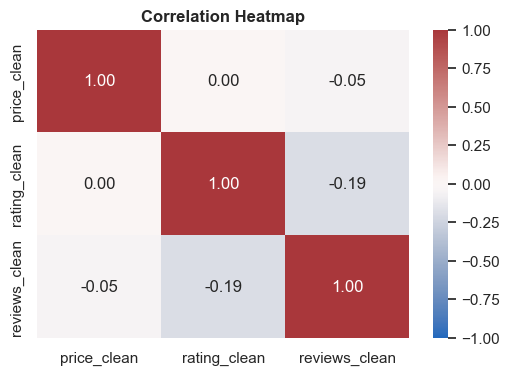

In [17]:
# Visual 3: Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap", fontweight="bold")
plt.savefig("eda_summary.png", dpi=120, bbox_inches="tight")
plt.show()


## Q9: How do we export the cleaned dataset for downstream SQL and Power BI?

### Concept Pointers:
- Save standardized dataset to `data/ecommerce_cleaned.csv`.

In [18]:
export_cols = ["listing_id", "name", "brand", "category", "price_clean", "rating_clean", "reviews_clean"]
final_df = df_clean[export_cols].rename(columns={
    "price_clean": "price",
    "rating_clean": "rating",
    "reviews_clean": "review_count"
})

OUTPUT_PATH = "data/ecommerce_cleaned.csv"
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"[EXPORT] Exported {len(final_df)} clean rows to '{OUTPUT_PATH}'!")
final_df.head(3)


[EXPORT] Exported 103 clean rows to 'data/ecommerce_cleaned.csv'!


,listing_id,name,brand,category,price,rating,review_count
0,1,Maple Row Electric Kettle,Maple Row,home-goods,23.29,3.7,1269
1,2,Lumen Air Purifier,Lumen,home-goods,186.52,2.9,2408
3,4,Maple Row Wall Clock,Maple Row,home-goods,127.00,4.7,859


## Summary & Key Takeaways

- **Live Scraping**: Demonstrated HTTP request and DOM card parsing with `BeautifulSoup`.
- **Vectorized Cleaning**: Cleaned currency strings with regex and converted to continuous floats.
- **Outlier Detection**: Applied the non-parametric $1.5 \times \text{IQR}$ rule.
- **Hypothesis Testing**: Statistically validated price differences between categories ($p < 0.05$).
- **Data Hand-off**: Exported `ecommerce_cleaned.csv` directly feeding into **Sprint 3 (SQL)** and **Sprint 4 (Power BI)**!